# Russell 3000 — Twitter Sentiment Replication
**Ashley Thompson — Capstone**

Three studies using the Gu & Kurov (2020) Fama-MacBeth methodology on the Russell 3000 universe.

| Study | Period | Output |
|---|---|---|
| 1 — Original replication | 2016–2017 | Tables 2, 3, 5, 6 |
| 2 — Modern replication | 2024–2025 | Tables 2, 3, 5, 6 |
| 3 — Temporal heterogeneity | 2016–2026 | Monthly/quarterly/annual CSVs, figures, LaTeX |

**Input:** `russel_panel.csv`  
**Output:** LaTeX tables in `output/`, figures in `output/figures/`, CSVs in `data/processed/`

## 1. Install dependencies

In [1]:
!pip install -q linearmodels pandas_datareader statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.1 MB/s eta 0:00:00


## 2. Load data from Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Capstone/'
DATA_PATH = DRIVE_DIR + 'russel_panel.csv'
print(f'Using: {DATA_PATH}')
print(f'Exists: {os.path.exists(DATA_PATH)}')

Mounted at /content/drive
Using: /content/drive/MyDrive/Colab Notebooks/Capstone/russel_panel.csv
Exists: True


In [3]:
from google.colab import userdata
import os, subprocess

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO_DIR     = '/content/Capstone'

if os.path.exists(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)
else:
    subprocess.run(
        ['git', 'clone',
         f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git', REPO_DIR],
        check=True)
DATA_OUT = REPO_DIR + '/data/processed/'
os.makedirs(DATA_OUT, exist_ok=True)
os.makedirs(REPO_DIR + '/output/figures/', exist_ok=True)
print(f'Repo ready: {REPO_DIR}')

Repo ready: /content/Capstone


## 3. Imports and variable construction

In [4]:
import warnings
import numpy as np
import pandas as pd
from linearmodels.panel import FamaMacBeth

warnings.filterwarnings('ignore')
np.random.seed(42)

FF_CUTOFF = pd.Timestamp('2026-02-28')

long = pd.read_csv(DATA_PATH, parse_dates=['date'])
long = long[long['date'] <= FF_CUTOFF].reset_index(drop=True)
long = long.sort_values(['ticker', 'date']).reset_index(drop=True)
print(f'Loaded {len(long):,} rows x {long.shape[1]} cols')
print(f'Date range: {long["date"].min().date()} to {long["date"].max().date()}')
print(f'Tickers: {long["ticker"].nunique():,}')

HAS_SPREAD = 'bid_ask_spread' in long.columns
print(f'Bid-ask spread: {"AVAILABLE" if HAS_SPREAD else "MISSING"}')

Loaded 4,448,157 rows x 19 cols
Date range: 2016-01-04 to 2026-02-27
Tickers: 2,921
Bid-ask spread: AVAILABLE


In [5]:
long['px_open_next'] = long.groupby('ticker')['px_open'].shift(-1)
long['return_oo']    = (long['px_open_next'] - long['px_open']) / long['px_open'] * 100

lH = np.log(long['px_high'].clip(lower=1e-8))
lL = np.log(long['px_low'].clip(lower=1e-8))
lO = np.log(long['px_open'].clip(lower=1e-8))
lC = np.log(long['px_close'].clip(lower=1e-8))
long['vol_rs'] = ((lH-lC)*(lH-lO) + (lL-lC)*(lL-lO)).clip(lower=0) * 100

mv = long.groupby('ticker')['volume'].transform('mean')
long['abnorm_vol']  = ((long['volume'] - mv) / mv) * 100
long['log_mkt_cap'] = np.log(long['mkt_cap'].clip(lower=1e-8))

ctrl_base = ['return_oo', 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
if HAS_SPREAD:
    ctrl_base.append('bid_ask_spread')

for var in ctrl_base:
    for k in range(1, 6):
        long[f'{var}_lag{k}'] = long.groupby('ticker')[var].shift(k)

for k in range(1, 6):
    long[f'twitter_sent_lag{k}'] = long.groupby('ticker')['twitter_sent'].shift(k)
    long[f'news_sent_lag{k}']    = long.groupby('ticker')['news_sent'].shift(k)

print(f'return_oo: {long["return_oo"].notna().sum():,} obs')
print('Variable construction complete.')

return_oo: 4,445,236 obs
Variable construction complete.


## 4. Fama-French risk adjustment
Full-sample betas estimated once; residuals are used within each study window.

In [6]:
import statsmodels.api as sm
import pandas_datareader.data as web

HAS_ADJ_RETURN = False

try:
    s, e = long['date'].min(), long['date'].max()
    ff3  = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=s, end=e)[0]
    mom  = web.DataReader('F-F_Momentum_Factor_daily',       'famafrench', start=s, end=e)[0]
    ff3.index = pd.to_datetime(ff3.index, format='%Y%m%d')
    mom.index = pd.to_datetime(mom.index, format='%Y%m%d')
    ff  = ff3.join(mom, how='inner') / 100
    ff.columns = [c.strip() for c in ff.columns]
    print(f'FF factors: {ff.shape[0]} days, cols: {list(ff.columns)}')

    merged = long.merge(
        ff.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','Mom':'mom'}),
        left_on='date', right_index=True, how='left')
    residuals = np.full(len(merged), np.nan)
    for ticker, grp in merged.groupby('ticker'):
        sub = grp[['return_oo','mkt_rf','smb','hml','mom']].dropna()
        if len(sub) < 30: continue
        X = sm.add_constant(sub[['mkt_rf','smb','hml','mom']])
        residuals[sub.index] = sm.OLS(sub['return_oo'], X).fit().resid.values
    long['return_oo_adj'] = residuals

    for k in range(1, 6):
        long[f'return_oo_adj_lag{k}'] = long.groupby('ticker')['return_oo_adj'].shift(k)

    HAS_ADJ_RETURN = long['return_oo_adj'].notna().sum() > 1000
    print(f'Risk-adjusted returns: {long["return_oo_adj"].notna().sum():,} obs')

except Exception as ex:
    print(f'FF download failed: {ex}')
    print('Using raw returns throughout.')

DEP_VAR          = 'return_oo_adj' if HAS_ADJ_RETURN else 'return_oo'
DEFAULT_OTH_VARS = ([DEP_VAR, 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
                    + (['bid_ask_spread'] if HAS_SPREAD else []))
print(f'Dependent variable: {DEP_VAR}')
print(f'Confounders:        {DEFAULT_OTH_VARS}')

FF factors: 2553 days, cols: ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']
Risk-adjusted returns: 4,445,178 obs
Dependent variable: return_oo_adj
Confounders:        ['return_oo_adj', 'abnorm_vol', 'vol_rs', 'log_mkt_cap', 'bid_ask_spread']


## 5. Helper functions

In [7]:
NR_LAGS = [1, 2, 3, 4, 5]

def stars(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fmt(v, decimals=4):
    return f'{v:.{decimals}f}' if not pd.isna(v) else '---'

def fit_fmb(dep_var, treatment_cols, data, oth_vars=None,
            n_lags=5, bandwidth=5, min_cs=30):
    if oth_vars is None:
        oth_vars = DEFAULT_OTH_VARS
    controls = [f'{v}_lag{k}' for v in oth_vars for k in range(1, n_lags+1)]
    formula  = dep_var + ' ~ ' + ' + '.join(treatment_cols + controls)
    try:
        panel = data.set_index(['ticker','date']) if 'ticker' in data.columns else data
        cs    = panel.groupby(level='date').size()
        valid = set(cs[cs >= min_cs].index)
        for col in treatment_cols + controls:
            if col in panel.columns:
                cv = panel.groupby(level='date')[col].std()
                valid -= set(cv[cv.isna() | (cv == 0)].index)
        panel = panel[panel.index.get_level_values('date').isin(valid)]
        if panel.index.get_level_values('date').nunique() < 10:
            return None
        mod = FamaMacBeth.from_formula(formula, data=panel)
        try:
            return mod.fit(cov_type='kernel', bandwidth=bandwidth)
        except Exception:
            try:    return mod.fit(cov_type='robust')
            except: return None
    except Exception:
        return None

def extract_fmb(res, param):
    if res is None or param not in res.params.index:
        return {'coef': np.nan, 'se': np.nan, 'pval': np.nan, 'stars': ''}
    c, s, pv = float(res.params[param]), float(res.std_errors[param]), float(res.pvalues[param])
    return {'coef': c, 'se': s, 'pval': pv, 'stars': stars(pv)}

def long_short_stats(data):
    df = data[['date','ticker','twitter_sent','return_oo']].dropna().copy()
    df['pct_rank'] = df.groupby('date')['twitter_sent'].rank(pct=True)
    df['side']     = df['pct_rank'].apply(
        lambda r: 'long' if r >= 0.9 else ('short' if r <= 0.1 else None))
    df = df.dropna(subset=['side','return_oo'])
    daily = (df.groupby(['date','side'])['return_oo']
               .mean().unstack('side').dropna(subset=['long','short']))
    if daily.empty:
        return {'ls_mean_daily':np.nan,'ls_ann_return':np.nan,
                'ls_sharpe':np.nan,'ls_win_rate':np.nan,'ls_n_days':0}
    daily['ls'] = daily['long'] - daily['short']
    mu, sigma = daily['ls'].mean(), daily['ls'].std()
    return {'ls_mean_daily': mu, 'ls_ann_return': mu*252,
            'ls_sharpe': (mu/sigma)*np.sqrt(252) if sigma > 0 else np.nan,
            'ls_win_rate': (daily['ls'] > 0).mean(), 'ls_n_days': len(daily)}

print('All helper functions defined.')

All helper functions defined.


## 6. LaTeX table builders (Studies 1 & 2)

In [8]:
import os
TEX_OUT = REPO_DIR + '/output/'
os.makedirs(TEX_OUT, exist_ok=True)

def _ctrl_note():
    base = r'5 lags each of return, abnorm\_vol, vol\_rs, log\_mkt\_cap'
    return base + (r', bid\_ask\_spread' if HAS_SPREAD else '')

def latex_t2(est_raw, est_adj, period_label, prefix):
    def cell(est):
        if pd.isna(est['coef']): return '---', '---'
        return f"${fmt(est['coef'])}{est['stars']}$", f"$({fmt(est['se'])})$"
    c1, s1 = cell(est_raw)
    c2, s2 = cell(est_adj)
    tex = (
        r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
        f'\\caption{{Return Predictability ({period_label}) --- Russell 3000}}\n'
        f'\\label{{tab:{prefix}_t2}}\n'
        r'\begin{tabular}{lcc}' + '\n' + r'\hline\hline' + '\n'
        r' & (1) Raw Return & (2) Risk-Adj \\' + '\n' + r'\hline' + '\n'
        f'twitter\\_sent\\_lag1 & {c1} & {c2} \\\\\n'
        f'                     & {s1} & {s2} \\\\\n'
        r'\hline' + '\n'
        r'Estimator & Fama-MacBeth & Fama-MacBeth \\' + '\n'
        r'SE & Newey-West (5) & Newey-West (5) \\' + '\n'
        r'\hline\hline' + '\n'
        r'\multicolumn{3}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
        r'Fama-MacBeth with Newey-West SEs (5 lags). Open-to-open return. '
        r'Controls: ' + _ctrl_note() + r'. '
        r'Risk-Adj = Fama-French-Carhart 4-factor residual. '
        r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.}\n'
        r'\end{tabular}' + '\n' + r'\end{table}'
    )
    with open(TEX_OUT + f'{prefix}_t2.tex', 'w') as f: f.write(tex)
    print(f'  Saved {prefix}_t2.tex')

def latex_t3(nr_res, period_label, prefix):
    rows = []
    for k in NR_LAGS:
        est = extract_fmb(nr_res, f'twitter_sent_lag{k}')
        c = f"${fmt(est['coef'])}{est['stars']}$" if not pd.isna(est['coef']) else '---'
        s = f"$({fmt(est['se'])})$"               if not pd.isna(est['coef']) else '---'
        rows.append(f'twitter\\_sent\\_lag{k} & {c} \\\\\n               & {s} \\\\')
    tex = (
        r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
        f'\\caption{{No-Reversal Test ({period_label}) --- Russell 3000}}\n'
        f'\\label{{tab:{prefix}_t3}}\n'
        r'\begin{tabular}{lc}' + '\n' + r'\hline\hline' + '\n'
        r' & Risk-Adj \\' + '\n' + r'\hline' + '\n'
        + '\n'.join(rows) + '\n'
        + r'\hline' + '\n'
        r'Estimator & Fama-MacBeth \\' + '\n'
        r'SE & Newey-West (5) \\' + '\n'
        r'\hline\hline' + '\n'
        r'\multicolumn{2}{p{0.85\linewidth}}{\footnotesize \textit{Notes:} '
        r'All 5 lags entered jointly. Pass criterion: lag 1 significant, '
        r'lags 2--5 insignificant (Gu \& Kurov, 2020). '
        r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.}\n'
        r'\end{tabular}' + '\n' + r'\end{table}'
    )
    with open(TEX_OUT + f'{prefix}_t3.tex', 'w') as f: f.write(tex)
    print(f'  Saved {prefix}_t3.tex')

def latex_t5(res_news, res_joint, period_label, prefix):
    def cell(res, param):
        est = extract_fmb(res, param)
        if pd.isna(est['coef']): return '---', '---'
        return f"${fmt(est['coef'])}{est['stars']}$", f"$({fmt(est['se'])})$"
    ne_c, ne_s = cell(res_news,  'news_sent_lag1')
    tw_c, tw_s = cell(res_joint, 'twitter_sent_lag1')
    nj_c, nj_s = cell(res_joint, 'news_sent_lag1')
    tex = (
        r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
        f'\\caption{{Twitter vs.\\ News Sentiment ({period_label}) --- Russell 3000}}\n'
        f'\\label{{tab:{prefix}_t5}}\n'
        r'\begin{tabular}{lcc}' + '\n' + r'\hline\hline' + '\n'
        r' & (1) News Only & (2) Twitter + News \\' + '\n' + r'\hline' + '\n'
        f'twitter\\_sent\\_lag1 & --- & {tw_c} \\\\\n'
        f'                     & --- & {tw_s} \\\\\n'
        f'news\\_sent\\_lag1    & {ne_c} & {nj_c} \\\\\n'
        f'                     & {ne_s} & {nj_s} \\\\\n'
        r'\hline' + '\n'
        r'Estimator & Fama-MacBeth & Fama-MacBeth \\' + '\n'
        r'SE & Newey-West (5) & Newey-West (5) \\' + '\n'
        r'\hline\hline' + '\n'
        r'\multicolumn{3}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
        r'Both sentiments use 1-day lag. Risk-adjusted open-to-open return. '
        r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.}\n'
        r'\end{tabular}' + '\n' + r'\end{table}'
    )
    with open(TEX_OUT + f'{prefix}_t5.tex', 'w') as f: f.write(tex)
    print(f'  Saved {prefix}_t5.tex')

def latex_t6(ls, period_label, prefix):
    n_days = int(ls['ls_n_days']) if ls['ls_n_days'] > 0 else '---'
    tex = (
        r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
        f'\\caption{{Long-Short Strategy ({period_label}) --- Russell 3000}}\n'
        f'\\label{{tab:{prefix}_t6}}\n'
        r'\begin{tabular}{lc}' + '\n' + r'\hline\hline' + '\n'
        r'Statistic & Value \\' + '\n' + r'\hline' + '\n'
        f'Mean daily L-S return (\\%) & {fmt(ls["ls_mean_daily"])} \\\\\n'
        f'Annualized return (\\%)     & {fmt(ls["ls_ann_return"], 2)} \\\\\n'
        f'Annualized Sharpe           & {fmt(ls["ls_sharpe"],     2)} \\\\\n'
        f'Win rate                    & {fmt(ls["ls_win_rate"],   3)} \\\\\n'
        f'Trading days                & {n_days} \\\\\n'
        r'\hline\hline' + '\n'
        r'\multicolumn{2}{p{0.75\linewidth}}{\footnotesize \textit{Notes:} '
        r'Long (short) = top (bottom) decile daily Twitter sentiment. '
        r'24-hour hold. Before transaction costs. '
        r'Gu \& Kurov (2020) report Sharpe of 3.17 over Jan 2015--Feb 2017.}\n'
        r'\end{tabular}' + '\n' + r'\end{table}'
    )
    with open(TEX_OUT + f'{prefix}_t6.tex', 'w') as f: f.write(tex)
    print(f'  Saved {prefix}_t6.tex')

def run_replication(sub, period_label, prefix, bandwidth=5, min_cs=30):
    print(f'\n{"="*60}')
    print(f'  STUDY: {period_label}  '
          f'({sub["date"].nunique()} dates, '
          f'{sub["ticker"].nunique():,} tickers, N={len(sub):,})')
    print('='*60)
    raw_oth = (['return_oo', 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
               + (['bid_ask_spread'] if HAS_SPREAD else []))

    print('  Table 2 — Return Predictability')
    res_raw = fit_fmb('return_oo', ['twitter_sent_lag1'], sub,
                      oth_vars=raw_oth, bandwidth=bandwidth, min_cs=min_cs)
    res_adj = fit_fmb(DEP_VAR, ['twitter_sent_lag1'], sub,
                      oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    est_raw = extract_fmb(res_raw, 'twitter_sent_lag1')
    est_adj = extract_fmb(res_adj, 'twitter_sent_lag1')
    latex_t2(est_raw, est_adj, period_label, prefix)
    print(f'    Raw: {fmt(est_raw["coef"])}{est_raw["stars"]}  '
          f'Adj: {fmt(est_adj["coef"])}{est_adj["stars"]}')

    print('  Table 3 — No-Reversal Test')
    nr_res = fit_fmb(DEP_VAR, [f'twitter_sent_lag{k}' for k in NR_LAGS], sub,
                     oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    latex_t3(nr_res, period_label, prefix)

    print('  Table 5 — Twitter vs. News Sentiment')
    res_news  = fit_fmb(DEP_VAR, ['news_sent_lag1'], sub,
                        oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    res_joint = fit_fmb(DEP_VAR, ['twitter_sent_lag1', 'news_sent_lag1'], sub,
                        oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    latex_t5(res_news, res_joint, period_label, prefix)

    print('  Table 6 — Long-Short Strategy')
    ls = long_short_stats(sub)
    latex_t6(ls, period_label, prefix)
    print(f'    Sharpe: {fmt(ls["ls_sharpe"], 2)}  '
          f'Ann. return: {fmt(ls["ls_ann_return"], 2)}%  '
          f'Win rate: {fmt(ls["ls_win_rate"], 3)}')

print('LaTeX builders and run_replication() defined.')

LaTeX builders and run_replication() defined.


## 7. Study 1 — Original period replication (2016–2017)

In [9]:
sub_2016 = long[
    (long['date'] >= pd.Timestamp('2016-01-01')) &
    (long['date'] <= pd.Timestamp('2017-12-31'))
].copy()
run_replication(sub_2016, '2016--2017', 'russel_2016')


  STUDY: 2016--2017  (503 dates, 1,949 tickers, N=829,672)
  Table 2 — Return Predictability
  Saved russel_2016_t2.tex
    Raw: -0.0023  Adj: -0.0092
  Table 3 — No-Reversal Test
  Saved russel_2016_t3.tex
  Table 5 — Twitter vs. News Sentiment
  Saved russel_2016_t5.tex
  Table 6 — Long-Short Strategy
  Saved russel_2016_t6.tex
    Sharpe: 0.72  Ann. return: 52.40%  Win rate: 0.781


## 8. Study 2 — Modern period replication (2024–2025)

In [10]:
sub_2024 = long[
    (long['date'] >= pd.Timestamp('2024-01-01')) &
    (long['date'] <= pd.Timestamp('2025-12-31'))
].copy()
run_replication(sub_2024, '2024--2025', 'russel_2024')


  STUDY: 2024--2025  (250 dates, 2,919 tickers, N=711,684)
  Table 2 — Return Predictability
  Saved russel_2024_t2.tex
    Raw: 0.2448***  Adj: 0.1937**
  Table 3 — No-Reversal Test
  Saved russel_2024_t3.tex
  Table 5 — Twitter vs. News Sentiment
  Saved russel_2024_t5.tex
  Table 6 — Long-Short Strategy
  Saved russel_2024_t6.tex
    Sharpe: 16.58  Ann. return: 205.75%  Win rate: 0.888


## 9. Study 3 — Long-term temporal analysis (2016–2026)
Monthly (bandwidth=3, min_cs=15), quarterly (bandwidth=4, min_cs=20), annual (bandwidth=5, min_cs=30).  
Expect several minutes for monthly (~122 windows).

In [11]:
def run_window(label, start, end, bandwidth, min_cs):
    sub     = long[(long['date'] >= start) & (long['date'] <= end)].copy()
    n_dates = sub['date'].nunique()
    row     = {'window_label': label, 'window_start': start.date(),
               'window_end': end.date(), 'n_dates': n_dates,
               'n_obs': len(sub), 'dep_var': DEP_VAR}
    nan_cols = (['fmb_coef','fmb_se','fmb_pval','fmb_stars']
                + [f'nr_lag{k}_{s}' for k in NR_LAGS for s in ['coef','se','pval','stars']]
                + ['ls_mean_daily','ls_ann_return','ls_sharpe','ls_win_rate','ls_n_days'])
    if n_dates < 10:
        for c in nan_cols: row[c] = '' if 'stars' in c else (0 if c=='ls_n_days' else np.nan)
        return row
    res = fit_fmb(DEP_VAR, ['twitter_sent_lag1'], sub,
                  oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    est = extract_fmb(res, 'twitter_sent_lag1')
    row.update({'fmb_coef':est['coef'],'fmb_se':est['se'],
                'fmb_pval':est['pval'],'fmb_stars':est['stars']})
    nr_res = fit_fmb(DEP_VAR, [f'twitter_sent_lag{k}' for k in NR_LAGS], sub,
                     oth_vars=DEFAULT_OTH_VARS, bandwidth=bandwidth, min_cs=min_cs)
    for k in NR_LAGS:
        est = extract_fmb(nr_res, f'twitter_sent_lag{k}')
        row.update({f'nr_lag{k}_coef':est['coef'], f'nr_lag{k}_se':est['se'],
                    f'nr_lag{k}_pval':est['pval'], f'nr_lag{k}_stars':est['stars']})
    row.update(long_short_stats(sub))
    return row

def monthly_windows(start_year=2016, end=(2026, 2)):
    windows, y, m = [], start_year, 1
    while (y, m) <= end:
        s = pd.Timestamp(y, m, 1)
        e = s + pd.offsets.MonthEnd(0)
        windows.append((s.strftime('%Y-%m'), s, e))
        m += 1
        if m > 12: m, y = 1, y + 1
    return windows

def quarterly_windows(start_year=2016, end=(2026, 1)):
    windows = []
    for y in range(start_year, end[0] + 1):
        for q in range(1, 5):
            qm = (q - 1) * 3 + 1
            s  = pd.Timestamp(y, qm, 1)
            e  = pd.Timestamp(y, qm + 2, 1) + pd.offsets.MonthEnd(0)
            if s > pd.Timestamp(end[0], (end[1]-1)//3*3+1, 1): return windows
            windows.append((f'{y}-Q{q}', s, e))
    return windows

def annual_windows(start_year=2016, end_year=2026):
    windows = []
    for y in range(start_year, end_year + 1):
        s = pd.Timestamp(y, 1, 1)
        e = pd.Timestamp(y, 2, 28) if y == 2026 else pd.Timestamp(y, 12, 31)
        windows.append((str(y) if y < 2026 else '2026 (Jan-Feb)', s, e))
    return windows

print(f'Monthly windows:   {len(monthly_windows())}')
print(f'Quarterly windows: {len(quarterly_windows())}')
print(f'Annual windows:    {len(annual_windows())}')

Monthly windows:   122
Quarterly windows: 41
Annual windows:    11


In [12]:
FREQ_CONFIG = [
    ('monthly',   monthly_windows(),   3, 15),
    ('quarterly', quarterly_windows(), 4, 20),
    ('annual',    annual_windows(),    5, 30),
]

temporal_dfs = {}

for freq, windows, bw, mcs in FREQ_CONFIG:
    print(f'\n{"="*60}')
    print(f'  TEMPORAL {freq.upper()} ({len(windows)} windows, bandwidth={bw}, min_cs={mcs})')
    print('='*60)
    rows = []
    for label, start, end in windows:
        row = run_window(label, start, end, bandwidth=bw, min_cs=mcs)
        rows.append(row)
        c  = f'{row["fmb_coef"]:>8.4f}' if not pd.isna(row["fmb_coef"]) else '     n/a'
        sh = f'{row["ls_sharpe"]:>5.2f}'  if not pd.isna(row["ls_sharpe"]) else '  n/a'
        print(f'  {label:<16}  FMB={c}{row["fmb_stars"]:3s}  '
              f'Sharpe={sh}  n_dates={row["n_dates"]:>3d}')
    temporal_dfs[freq] = pd.DataFrame(rows)

monthly_df   = temporal_dfs['monthly']
quarterly_df = temporal_dfs['quarterly']
annual_df    = temporal_dfs['annual']

print(f'\nmonthly_df:   {monthly_df.shape}')
print(f'quarterly_df: {quarterly_df.shape}')
print(f'annual_df:    {annual_df.shape}')


  TEMPORAL MONTHLY (122 windows, bandwidth=3, min_cs=15)
  2016-01           FMB=  0.0735     Sharpe=-3.32  n_dates= 19
  2016-02           FMB=  0.0588     Sharpe=14.48  n_dates= 20
  2016-03           FMB= -0.0656     Sharpe=10.96  n_dates= 22
  2016-04           FMB= -0.0605     Sharpe=15.51  n_dates= 21
  2016-05           FMB=  0.2142**   Sharpe=16.01  n_dates= 21
  2016-06           FMB=  0.0123     Sharpe=23.60  n_dates= 22
  2016-07           FMB=  0.0365     Sharpe=11.19  n_dates= 20
  2016-08           FMB=  0.3037**   Sharpe=21.69  n_dates= 23
  2016-09           FMB=  0.1208     Sharpe=12.73  n_dates= 21
  2016-10           FMB=  0.1765**   Sharpe=14.51  n_dates= 21
  2016-11           FMB=  0.0033     Sharpe=13.39  n_dates= 21
  2016-12           FMB=  0.1257**   Sharpe=15.47  n_dates= 21
  2017-01           FMB=  0.1327**   Sharpe=-2.41  n_dates= 20
  2017-02           FMB= -0.2116**   Sharpe= 8.48  n_dates= 19
  2017-03           FMB= -0.1154     Sharpe= 8.62  n_dates= 

## 10. Annual summary

In [13]:
print('='*70)
print('  Annual FMB coefficient on twitter_sent_lag1 — Russell 3000')
print('='*70)
print(f'  {"Year":<20} {"FMB coef":>10} {"SE":>10} {"p-val":>8} {"Stars":>6} {"Sharpe":>8}')
print('-'*68)
for _, r in annual_df.iterrows():
    coef   = f'{r["fmb_coef"]:>10.4f}' if not pd.isna(r["fmb_coef"]) else '         n/a'
    se     = f'{r["fmb_se"]:>10.4f}'   if not pd.isna(r["fmb_se"])   else '         n/a'
    pval   = f'{r["fmb_pval"]:>8.4f}'  if not pd.isna(r["fmb_pval"]) else '     n/a'
    sharpe = f'{r["ls_sharpe"]:>8.2f}' if not pd.isna(r["ls_sharpe"]) else '     n/a'
    st     = r['fmb_stars'] or ''
    print(f'  {r["window_label"]:<20} {coef} {se} {pval} {st:>6} {sharpe}')

  Annual FMB coefficient on twitter_sent_lag1 — Russell 3000
  Year                   FMB coef         SE    p-val  Stars   Sharpe
--------------------------------------------------------------------
  2016                     0.0847     0.0359   0.0181     **     0.47
  2017                    -0.1016     0.0368   0.0057    ***     8.06
  2018                     0.3373     0.0698   0.0000    ***    19.68
  2019                     0.3309     0.0669   0.0000    ***    20.92
  2020                     0.2427     0.1081   0.0248     **     9.38
  2021                     0.3524     0.1301   0.0068    ***     8.21
  2022                          n/a          n/a      n/a             n/a
  2023                     0.3161     0.2545   0.2143            7.70
  2024                          n/a          n/a      n/a             n/a
  2025                     0.1937     0.0884   0.0284     **    16.58
  2026 (Jan-Feb)           0.0664     0.1475   0.6525           13.99


## 11. Temporal plots — three separate figures

Saved /content/Capstone/output/figures/russel_temporal_annual.png


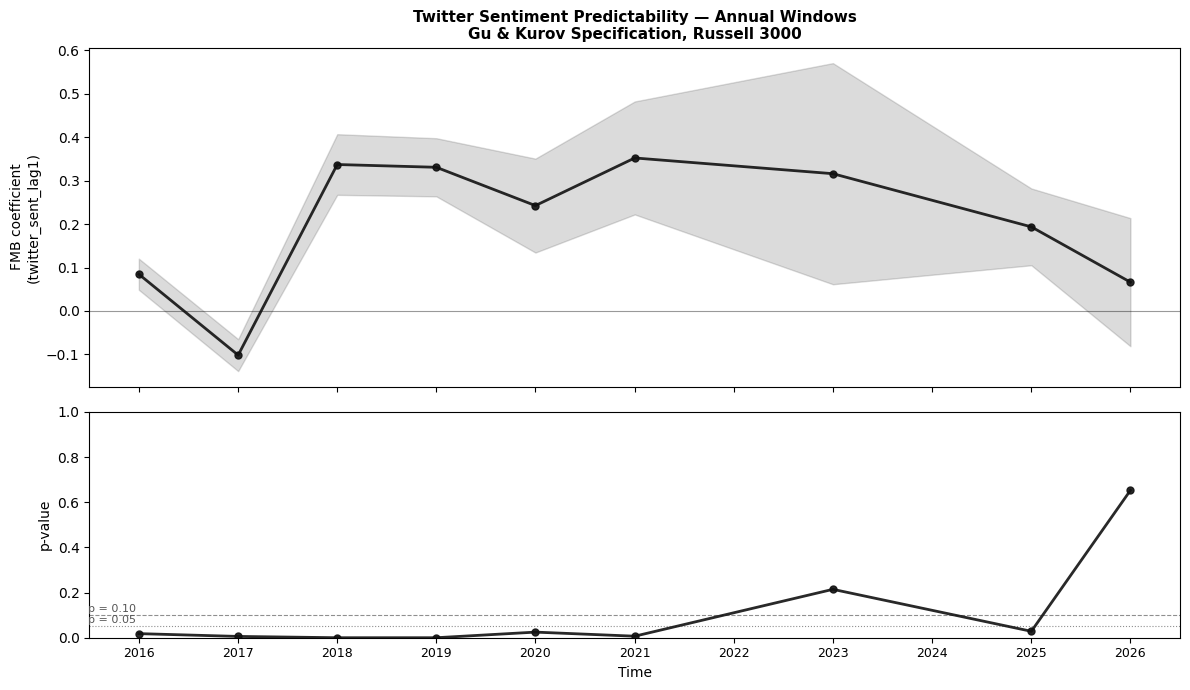

Saved /content/Capstone/output/figures/russel_temporal_quarterly.png


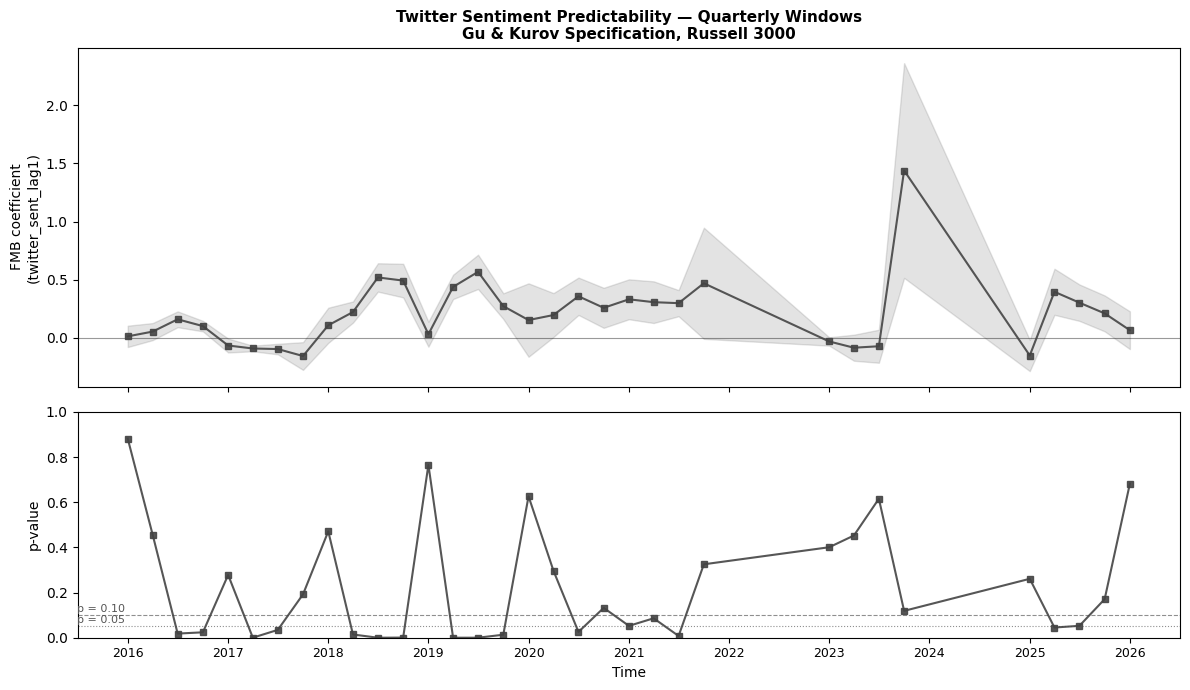

Saved /content/Capstone/output/figures/russel_temporal_monthly.png


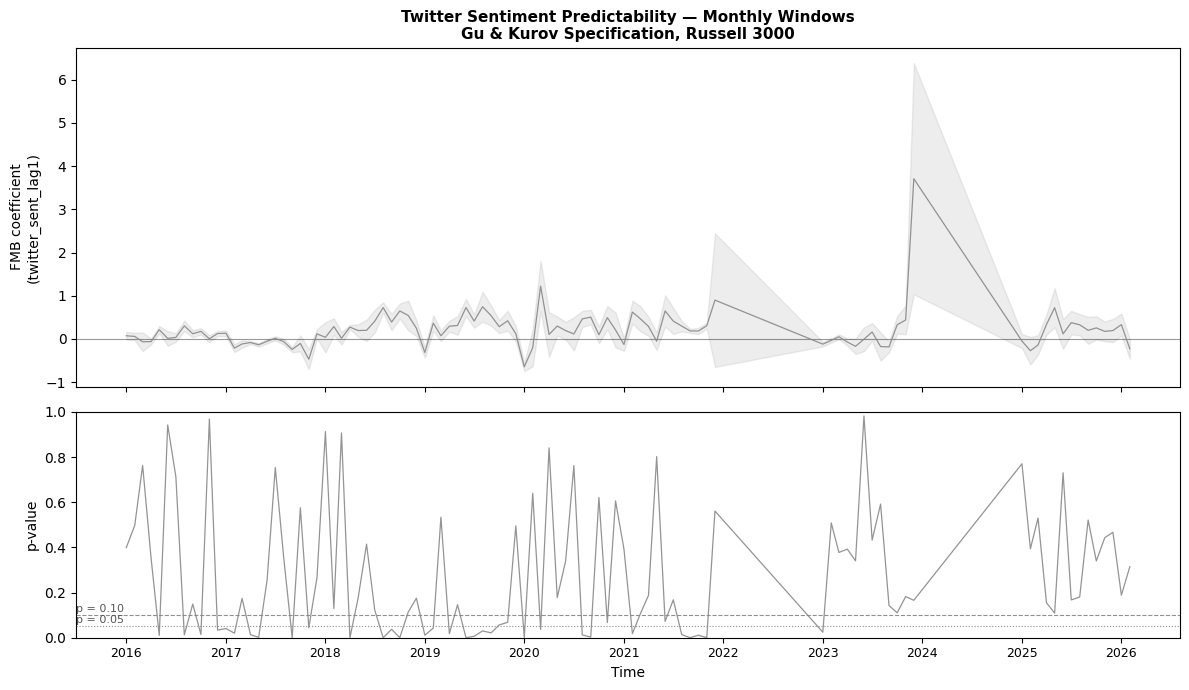

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

fig_path = REPO_DIR + '/output/figures/'
os.makedirs(fig_path, exist_ok=True)

def prep(df):
    d = df.copy()
    d['t'] = pd.to_datetime(d['window_start'])
    return d.dropna(subset=['fmb_coef','fmb_se','fmb_pval']).sort_values('t')

def plot_temporal(df, freq_label, color, lw, marker, out_name):
    d = prep(df)
    if d.empty:
        print(f'No valid data for {freq_label}.')
        return
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 7), sharex=True,
        gridspec_kw={'height_ratios': [3, 2]}
    )
    fig.subplots_adjust(hspace=0.25)
    t, coef, se, pval = d['t'], d['fmb_coef'], d['fmb_se'], d['fmb_pval']

    ax1.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
    ax1.plot(t, coef, color=color, linewidth=lw,
             marker=marker, markersize=5 if marker else 0, alpha=0.9)
    ax1.fill_between(t, coef - se, coef + se, color=color, alpha=0.15)
    ax1.set_ylabel('FMB coefficient\n(twitter_sent_lag1)', fontsize=10)
    ax1.set_title(
        f'Twitter Sentiment Predictability — {freq_label} Windows\n'
        f'Gu & Kurov Specification, Russell 3000',
        fontsize=11, fontweight='bold'
    )
    ax1.tick_params(axis='x', labelsize=9)

    ax2.axhline(0.10, color='#444444', linewidth=0.8, linestyle='--', alpha=0.6)
    ax2.axhline(0.05, color='#444444', linewidth=0.8, linestyle=':',  alpha=0.6)
    t_left = t.iloc[0] - pd.Timedelta(days=10)
    ax2.text(t_left, 0.105, 'p = 0.10', fontsize=8, color='#555555',
             va='bottom', ha='right')
    ax2.text(t_left, 0.055, 'p = 0.05', fontsize=8, color='#555555',
             va='bottom', ha='right')
    ax2.plot(t, pval, color=color, linewidth=lw,
             marker=marker, markersize=5 if marker else 0, alpha=0.9)
    ax2.set_ylim(0, 1.0)
    ax2.set_ylabel('p-value', fontsize=10)
    ax2.set_xlabel('Time', fontsize=10)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.tick_params(axis='x', labelsize=9)

    fig.tight_layout()
    save_path = fig_path + out_name
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

plot_temporal(annual_df,    'Annual',    '#111111', 2.0, 'o',  'russel_temporal_annual.png')
plot_temporal(quarterly_df, 'Quarterly', '#444444', 1.5, 's',  'russel_temporal_quarterly.png')
plot_temporal(monthly_df,   'Monthly',   '#888888', 0.9, None, 'russel_temporal_monthly.png')

## 12. Temporal LaTeX exports

In [15]:
import os
TEX_OUT = REPO_DIR + '/output/'
os.makedirs(TEX_OUT, exist_ok=True)

def st(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# Figure environments
FREQ_FIGS = [
    ('annual',    'russel_temporal_annual.png',
     r'Annual windows. Bandwidth = 5 lags; minimum cross-section $N = 30$.'),
    ('quarterly', 'russel_temporal_quarterly.png',
     r'Quarterly windows. Bandwidth = 4 lags; minimum cross-section $N = 20$.'),
    ('monthly',   'russel_temporal_monthly.png',
     r'Monthly windows. Bandwidth = 3 lags; minimum cross-section $N = 15$.'),
]
parts = []
for freq, fname, note in FREQ_FIGS:
    parts.append(
        r'\begin{figure}[htbp]' + '\n'
        r'\centering' + '\n'
        f'\\includegraphics[width=\\linewidth]{{figures/{fname}}}\n'
        r'\caption{Twitter Sentiment Predictability Over Time --- '
        f'Gu \\& Kurov Specification, Russell 3000 ({freq.capitalize()} windows). '
        r'Top panel: Fama-MacBeth coefficient on \texttt{twitter\_sent\_lag1} '
        r'with $\pm$1 SE band. Bottom panel: $p$-value; dashed lines '
        r'at $p = 0.10$ and $p = 0.05$. '
        + note + r'}' + '\n'
        f'\\label{{fig:russel_temporal_{freq}}}\n'
        r'\end{figure}'
    )
with open(TEX_OUT + 'russel_temporal_fig.tex', 'w') as f:
    f.write('\n\n'.join(parts))
print('Saved russel_temporal_fig.tex  (3 figure environments)')

# Summary statistics
sum_vars = {
    r'return\_oo':     'return_oo',
    r'twitter\_sent':  'twitter_sent',
    r'news\_sent':     'news_sent',
    r'vol\_rs':        'vol_rs',
    r'abnorm\_vol':    'abnorm_vol',
    r'log\_mkt\_cap': 'log_mkt_cap',
}
if HAS_SPREAD:     sum_vars[r'bid\_ask\_spread'] = 'bid_ask_spread'
if HAS_ADJ_RETURN: sum_vars[r'return\_oo\_adj']  = 'return_oo_adj'
sum_rows = []
for label, col in sum_vars.items():
    if col not in long.columns: continue
    s = long[col].dropna()
    sum_rows.append(
        f'  {label} & {fmt(s.mean())} & {fmt(s.std())} & '
        f'{fmt(s.min())} & {fmt(s.max())} & {len(s):,} \\\\'
    )
tex_ss = (
    r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
    r'\caption{Summary Statistics --- Russell 3000 Panel (2016--2026)}' + '\n'
    r'\label{tab:russel_sumstats}' + '\n'
    r'\begin{tabular}{lrrrrr}' + '\n' + r'\hline\hline' + '\n'
    r'Variable & Mean & SD & Min & Max & $N$ \\' + '\n' + r'\hline' + '\n'
    + '\n'.join(sum_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{6}{p{0.95\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Daily firm-level panel. return\_oo = open-to-open return (\%). '
    + r'vol\_rs = Rogers-Satchell realized volatility. '
    + r'abnorm\_vol = abnormal volume (\% deviation from ticker mean). '
    + r'log\_mkt\_cap = log market capitalization.'
    + (r' return\_oo\_adj = Fama-French-Carhart 4-factor residual.' if HAS_ADJ_RETURN else '')
    + r'} \\' + '\n' + r'\end{tabular}' + '\n' + r'\end{table}'
)
with open(TEX_OUT + 'russel_temporal_sumstats.tex', 'w') as f: f.write(tex_ss)
print('Saved russel_temporal_sumstats.tex')

# FMB annual table
ann = annual_df.copy()
fmb_rows = []
for _, r in ann.iterrows():
    sig = st(r['fmb_pval'])
    n   = f"{int(r['n_obs']):,}" if not pd.isna(r['n_obs']) else '---'
    fmb_rows.append(
        f"  {r['window_label']} & ${fmt(r['fmb_coef'])}{sig}$ "
        f"& $({fmt(r['fmb_se'])})$ & ${fmt(r['fmb_pval'])}$ & {n} \\\\"
    )
tex_fmb = (
    r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
    r'\caption{FMB Return Predictability by Year --- Russell 3000}' + '\n'
    r'\label{tab:russel_fmb_annual}' + '\n'
    r'\begin{tabular}{lcccc}' + '\n' + r'\hline\hline' + '\n'
    r'Year & Coef & (SE) & $p$-value & $N$ \\' + '\n' + r'\hline' + '\n'
    + '\n'.join(fmb_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{5}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Fama-MacBeth regression with Newey-West SEs (bandwidth = 5). '
    + f'Dependent variable: \\texttt{{{DEP_VAR}}}. '
    + r'Treatment: \texttt{twitter\_sent\_lag1}. '
    + r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.} \\' + '\n'
    + r'\end{tabular}' + '\n' + r'\end{table}'
)
with open(TEX_OUT + 'russel_temporal_fmb.tex', 'w') as f: f.write(tex_fmb)
print('Saved russel_temporal_fmb.tex')

# Long-short annual table
ls_rows = []
for _, r in ann.iterrows():
    n_d = int(r['ls_n_days']) if not pd.isna(r['ls_n_days']) else '---'
    ls_rows.append(
        f"  {r['window_label']} "
        f"& {fmt(r['ls_mean_daily'], 4)} "
        f"& {fmt(r['ls_ann_return'], 2)} "
        f"& {fmt(r['ls_sharpe'],     2)} "
        f"& {fmt(r['ls_win_rate'],   3)} "
        f"& {n_d} \\\\"
    )
tex_ls = (
    r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
    r'\caption{Long-Short Strategy Performance by Year --- Russell 3000}' + '\n'
    r'\label{tab:russel_ls_annual}' + '\n'
    r'\begin{tabular}{lccccc}' + '\n' + r'\hline\hline' + '\n'
    r'Year & Mean Daily (\%) & Ann. Return (\%) & Sharpe & Win Rate & Days \\' + '\n'
    r'\hline' + '\n'
    + '\n'.join(ls_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{6}{p{0.95\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Daily long-short portfolio. Long (short) = top (bottom) decile of '
    + r'contemporaneous Twitter sentiment. 24-hour holding period (open-to-open). '
    + r'Sharpe annualized assuming 252 trading days. Before transaction costs. '
    + r'Gu \& Kurov (2020) report Sharpe = 3.17 over Jan 2015--Feb 2017.} \\' + '\n'
    + r'\end{tabular}' + '\n' + r'\end{table}'
)
with open(TEX_OUT + 'russel_temporal_ls.tex', 'w') as f: f.write(tex_ls)
print('Saved russel_temporal_ls.tex')

print('\nAll LaTeX outputs written to', TEX_OUT)

Saved russel_temporal_fig.tex  (3 figure environments)
Saved russel_temporal_sumstats.tex
Saved russel_temporal_fmb.tex
Saved russel_temporal_ls.tex

All LaTeX outputs written to /content/Capstone/output/


## 13. Save CSVs and push to GitHub

In [16]:
monthly_df.to_csv(   DATA_OUT + 'russel_temporal_monthly.csv',   index=False)
quarterly_df.to_csv( DATA_OUT + 'russel_temporal_quarterly.csv', index=False)
annual_df.to_csv(    DATA_OUT + 'russel_temporal_annual.csv',    index=False)
print('Saved:')
print(f'  {DATA_OUT}russel_temporal_monthly.csv   ({len(monthly_df)} rows)')
print(f'  {DATA_OUT}russel_temporal_quarterly.csv ({len(quarterly_df)} rows)')
print(f'  {DATA_OUT}russel_temporal_annual.csv    ({len(annual_df)} rows)')

import os, subprocess
os.chdir(REPO_DIR)
subprocess.run(['git','config','user.email','althompson9@dons.usfca.edu'], check=True)
subprocess.run(['git','config','user.name', 'Ashley Thompson'],            check=True)
subprocess.run(['git', 'add',
    'data/processed/russel_temporal_monthly.csv',
    'data/processed/russel_temporal_quarterly.csv',
    'data/processed/russel_temporal_annual.csv',
    'output/figures/russel_temporal_annual.png',
    'output/figures/russel_temporal_quarterly.png',
    'output/figures/russel_temporal_monthly.png',
    'output/russel_2016_t2.tex', 'output/russel_2016_t3.tex',
    'output/russel_2016_t5.tex', 'output/russel_2016_t6.tex',
    'output/russel_2024_t2.tex', 'output/russel_2024_t3.tex',
    'output/russel_2024_t5.tex', 'output/russel_2024_t6.tex',
    'output/russel_temporal_fig.tex',
    'output/russel_temporal_sumstats.tex',
    'output/russel_temporal_fmb.tex',
    'output/russel_temporal_ls.tex'], check=True)
subprocess.run(['git','commit','-m',
    'Russell 3000 replication: 2016-2017, 2024-2025, and 2016-2026 temporal analysis'],
    check=True)
subprocess.run(['git','push',
    f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git','main'], check=True)
print('Pushed to GitHub.')

Saved:
  /content/Capstone/data/processed/russel_temporal_monthly.csv   (122 rows)
  /content/Capstone/data/processed/russel_temporal_quarterly.csv (41 rows)
  /content/Capstone/data/processed/russel_temporal_annual.csv    (11 rows)
Pushed to GitHub.
